# Учимся работе с данными - от загрузки до моделирования

In [2]:
#YOUR CODE HERE
#1.Скачайте датасет по ссылке: https://www.kaggle.com/uciml/breast-cancer-wisconsin-data
import kagglehub
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


# Download latest version
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

print("Path to dataset files:", path)

dc = pd.read_csv('/kaggle/input/breast-cancer-wisconsin-data/data.csv')
df = dc.copy()
df.head()

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
Path to dataset files: /kaggle/input/breast-cancer-wisconsin-data


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
#2.базовые статистики датасета
print("Размер датасета:", df.shape)
print("\nзначения целевой переменной:")
print(df['diagnosis'].unique())
print("\nПроверка на пропуски:")
print(df.isnull().sum())



Размер датасета: (569, 33)

значения целевой переменной:
['M' 'B']

Проверка на пропуски:
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave poi

Распределение целевой переменной:
diagnosis
B    357
M    212
Name: count, dtype: int64


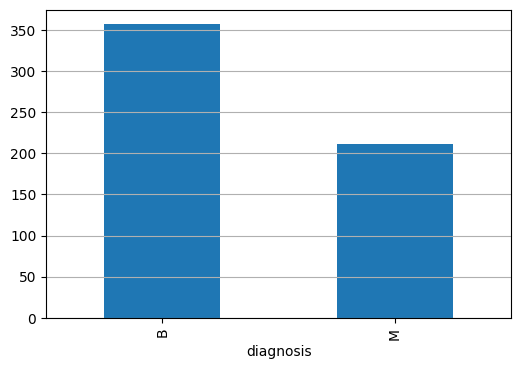

In [6]:

print(f"Распределение целевой переменной:\n{df['diagnosis'].value_counts()}")
df['diagnosis'].value_counts().plot.bar(figsize=(6, 4))
plt.grid(axis='y')
plt.show()

In [3]:

if 'id' and 'Unnamed: 32' in df.columns:
    df_clean = df.drop(['id','Unnamed: 32','diagnosis'], axis=1)
    df_clean['diagnosis_binary'] = df['diagnosis'].map({'B': 0, 'M': 1})
print(f"Индексы колонок:\n{df_clean.columns.tolist()}")

Индексы колонок:
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'diagnosis_binary']


In [61]:
print("\nИнформация о данных:")
print(df_clean.info())
print("\nСтатистическое описание:")
print(df_clean.describe())


Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   radius_mean              569 non-null    float64
 1   texture_mean             569 non-null    float64
 2   perimeter_mean           569 non-null    float64
 3   area_mean                569 non-null    float64
 4   smoothness_mean          569 non-null    float64
 5   compactness_mean         569 non-null    float64
 6   concavity_mean           569 non-null    float64
 7   concave points_mean      569 non-null    float64
 8   symmetry_mean            569 non-null    float64
 9   fractal_dimension_mean   569 non-null    float64
 10  radius_se                569 non-null    float64
 11  texture_se               569 non-null    float64
 12  perimeter_se             569 non-null    float64
 13  area_se                  569 non-null    float64
 14  smoo

In [15]:


print("🔄 СРАВНЕНИЕ СРЕДНИХ И МЕДИАН:")
comparison = pd.DataFrame({
    'Mean': df_clean.mean(),
    'Median': df_clean.median(),
    'Difference': df_clean.mean() - df_clean.median(),
    'Skewness': df_clean.skew()
})
print(comparison)


🔄 СРАВНЕНИЕ СРЕДНИХ И МЕДИАН:
                               Mean      Median  Difference  Skewness
radius_mean               14.127292   13.370000    0.757292  0.942380
texture_mean              19.289649   18.840000    0.449649  0.650450
perimeter_mean            91.969033   86.240000    5.729033  0.990650
area_mean                654.889104  551.100000  103.789104  1.645732
smoothness_mean            0.096360    0.095870    0.000490  0.456324
compactness_mean           0.104341    0.092630    0.011711  1.190123
concavity_mean             0.088799    0.061540    0.027259  1.401180
concave points_mean        0.048919    0.033500    0.015419  1.171180
symmetry_mean              0.181162    0.179200    0.001962  0.725609
fractal_dimension_mean     0.062798    0.061540    0.001258  1.304489
radius_se                  0.405172    0.324200    0.080972  3.088612
texture_se                 1.216853    1.108000    0.108853  1.646444
perimeter_se               2.866059    2.287000    0.579059 

In [16]:
# Статистика по классам диагноза
print("\n" + "="*60)
print("📊 СТАТИСТИКИ ПО КЛАССАМ ДИАГНОЗА:")
print(f"\nРаспределение классов:")
print(f"  Доброкачественные (B): {len(df_clean[df_clean['diagnosis_binary']==0])} ({(len(df_clean[df_clean['diagnosis_binary']==0])/len(df_clean)*100):.1f}%)")
print(f"  Злокачественные (M):   {len(df_clean[df_clean['diagnosis_binary']==1])} ({(len(df_clean[df_clean['diagnosis_binary']==1])/len(df_clean)*100):.1f}%)")

print("\nДоброкачественные (B):")
b_stats = df_clean[df_clean['diagnosis_binary']==0].describe()
print(f"  Средний радиус: {b_stats.loc['mean','radius_mean']:.2f}")
print(f"  Медианный радиус: {b_stats.loc['50%','radius_mean']:.2f}")
print(f"  Средняя площадь: {b_stats.loc['mean','area_mean']:.2f}")
print(f"  Медианная площадь: {b_stats.loc['50%','area_mean']:.2f}")
print(f"  Средняя площадь полости: {b_stats.loc['mean','concavity_mean']:.2f}")
print(f"  Медианная площадь полости: {b_stats.loc['50%','concavity_mean']:.2f}")

print("\nЗлокачественные (M):")
m_stats = df_clean[df_clean['diagnosis_binary']==1].describe()
print(f"  Средний радиус: {m_stats.loc['mean','radius_mean']:.2f}")
print(f"  Медианный радиус: {m_stats.loc['50%','radius_mean']:.2f}")
print(f"  Средняя площадь: {m_stats.loc['mean','area_mean']:.2f}")
print(f"  Медианная площадь: {m_stats.loc['50%','area_mean']:.2f}")
print(f"  Средняя площадь полости: {m_stats.loc['mean','concavity_mean']:.2f}")
print(f"  Медианная площадь полости: {m_stats.loc['50%','concavity_mean']:.2f}")


📊 СТАТИСТИКИ ПО КЛАССАМ ДИАГНОЗА:

Распределение классов:
  Доброкачественные (B): 357 (62.7%)
  Злокачественные (M):   212 (37.3%)

Доброкачественные (B):
  Средний радиус: 12.15
  Медианный радиус: 12.20
  Средняя площадь: 462.79
  Медианная площадь: 458.40
  Средняя площадь полости: 0.05
  Медианная площадь полости: 0.04

Злокачественные (M):
  Средний радиус: 17.46
  Медианный радиус: 17.33
  Средняя площадь: 978.38
  Медианная площадь: 932.00
  Средняя площадь полости: 0.16
  Медианная площадь полости: 0.15


In [62]:
# Выбросы
print("\n" + "="*60)
print("🔍 АНАЛИЗ ВЫБРОСОВ")

for diagnosis_binary in [0, 1]:
    subset = df_clean[df_clean['diagnosis_binary'] == diagnosis_binary]
    name = 'Доброкачественные' if diagnosis_binary == 0 else 'Злокачественные'
    print(f"{name}:")
    for feature in df_clean.columns.tolist():#['radius_worst', 'area_mean', 'concavity_mean']:
      Q1 = subset[feature].quantile(0.25)
      Q3 = subset[feature].quantile(0.75)
      IQR = Q3 - Q1
      lower_bound = Q1 - 1.5 * IQR
      upper_bound = Q3 + 1.5 * IQR
      outliers = subset[(subset[feature] < lower_bound) | (subset[feature] > upper_bound)]
      print(f"{feature}:")
      print(f"  IQR: {IQR:.2f}")
      print(f"  Границы: [{lower_bound:.2f}, {upper_bound:.2f}]")
      print(f"  Количество выбросов: {len(outliers)} ({(len(outliers)/len(df_clean)*100):.1f}%)")
      print()


🔍 АНАЛИЗ ВЫБРОСОВ
Доброкачественные:
radius_mean:
  IQR: 2.29
  Границы: [7.65, 16.80]
  Количество выбросов: 3 (0.5%)

texture_mean:
  IQR: 4.61
  Границы: [8.23, 26.68]
  Количество выбросов: 18 (3.2%)

perimeter_mean:
  IQR: 15.23
  Границы: [48.03, 108.94]
  Количество выбросов: 4 (0.7%)

area_mean:
  IQR: 172.90
  Границы: [118.85, 810.45]
  Количество выбросов: 4 (0.7%)

smoothness_mean:
  IQR: 0.02
  Границы: [0.06, 0.13]
  Количество выбросов: 4 (0.7%)

compactness_mean:
  IQR: 0.04
  Границы: [-0.01, 0.16]
  Количество выбросов: 9 (1.6%)

concavity_mean:
  IQR: 0.04
  Границы: [-0.04, 0.12]
  Количество выбросов: 12 (2.1%)

concave points_mean:
  IQR: 0.02
  Границы: [-0.01, 0.06]
  Количество выбросов: 17 (3.0%)

symmetry_mean:
  IQR: 0.03
  Границы: [0.11, 0.24]
  Количество выбросов: 10 (1.8%)

fractal_dimension_mean:
  IQR: 0.01
  Границы: [0.05, 0.08]
  Количество выбросов: 17 (3.0%)

radius_se:
  IQR: 0.13
  Границы: [0.01, 0.54]
  Количество выбросов: 9 (1.6%)

texture

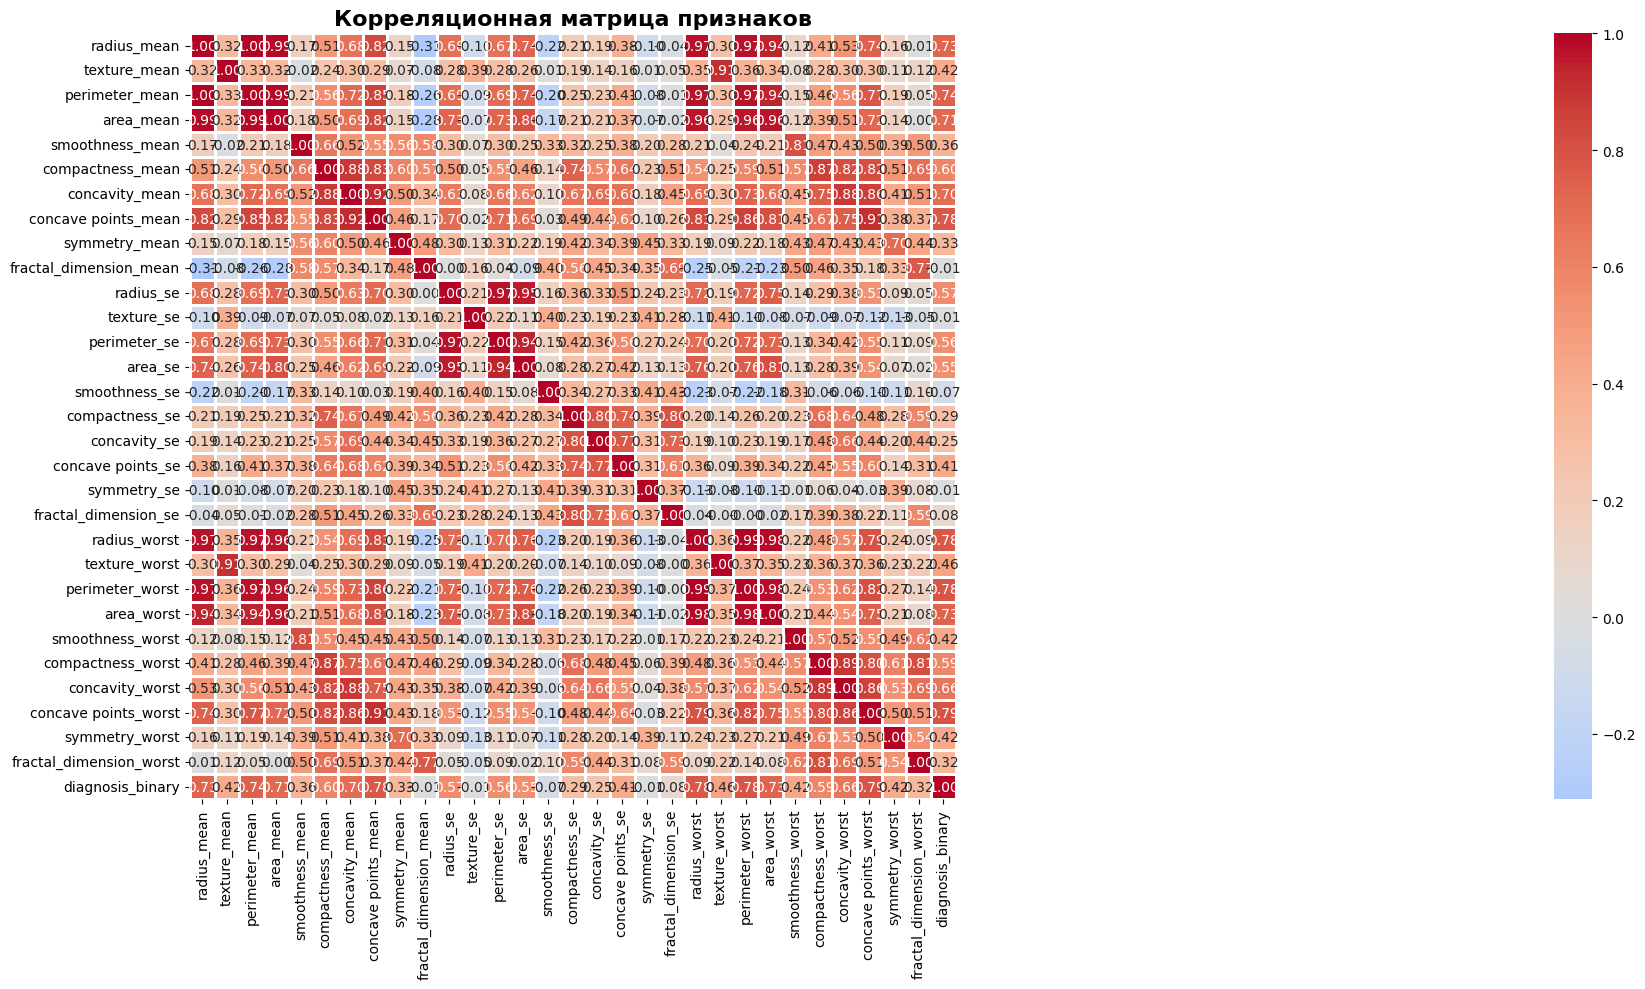

In [4]:
plt.figure(figsize=(120, 10))
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
correlation_matrix = df_clean[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.9)
plt.title('Корреляционная матрица признаков', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Постройте heatmap для матрицы корреляций, есть ли признаки, которые сильно скоррелированы? Какие это признаки?
Постройте для сильно скоррелированных признаков попарные scatterplot-ы, действительно ли наблюдается линейная зависимость?
Используя boxplots и группировку по целевой переменной, попробуйте предположить, по каким признакам наиболее удобно было бы отделить злокачественные новообразования от доброкачественных.

  Найдено 29 пар с |r| > 0.85



/tmp/ipykernel_4513/733797238.py:54: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4513/733797238.py:54: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


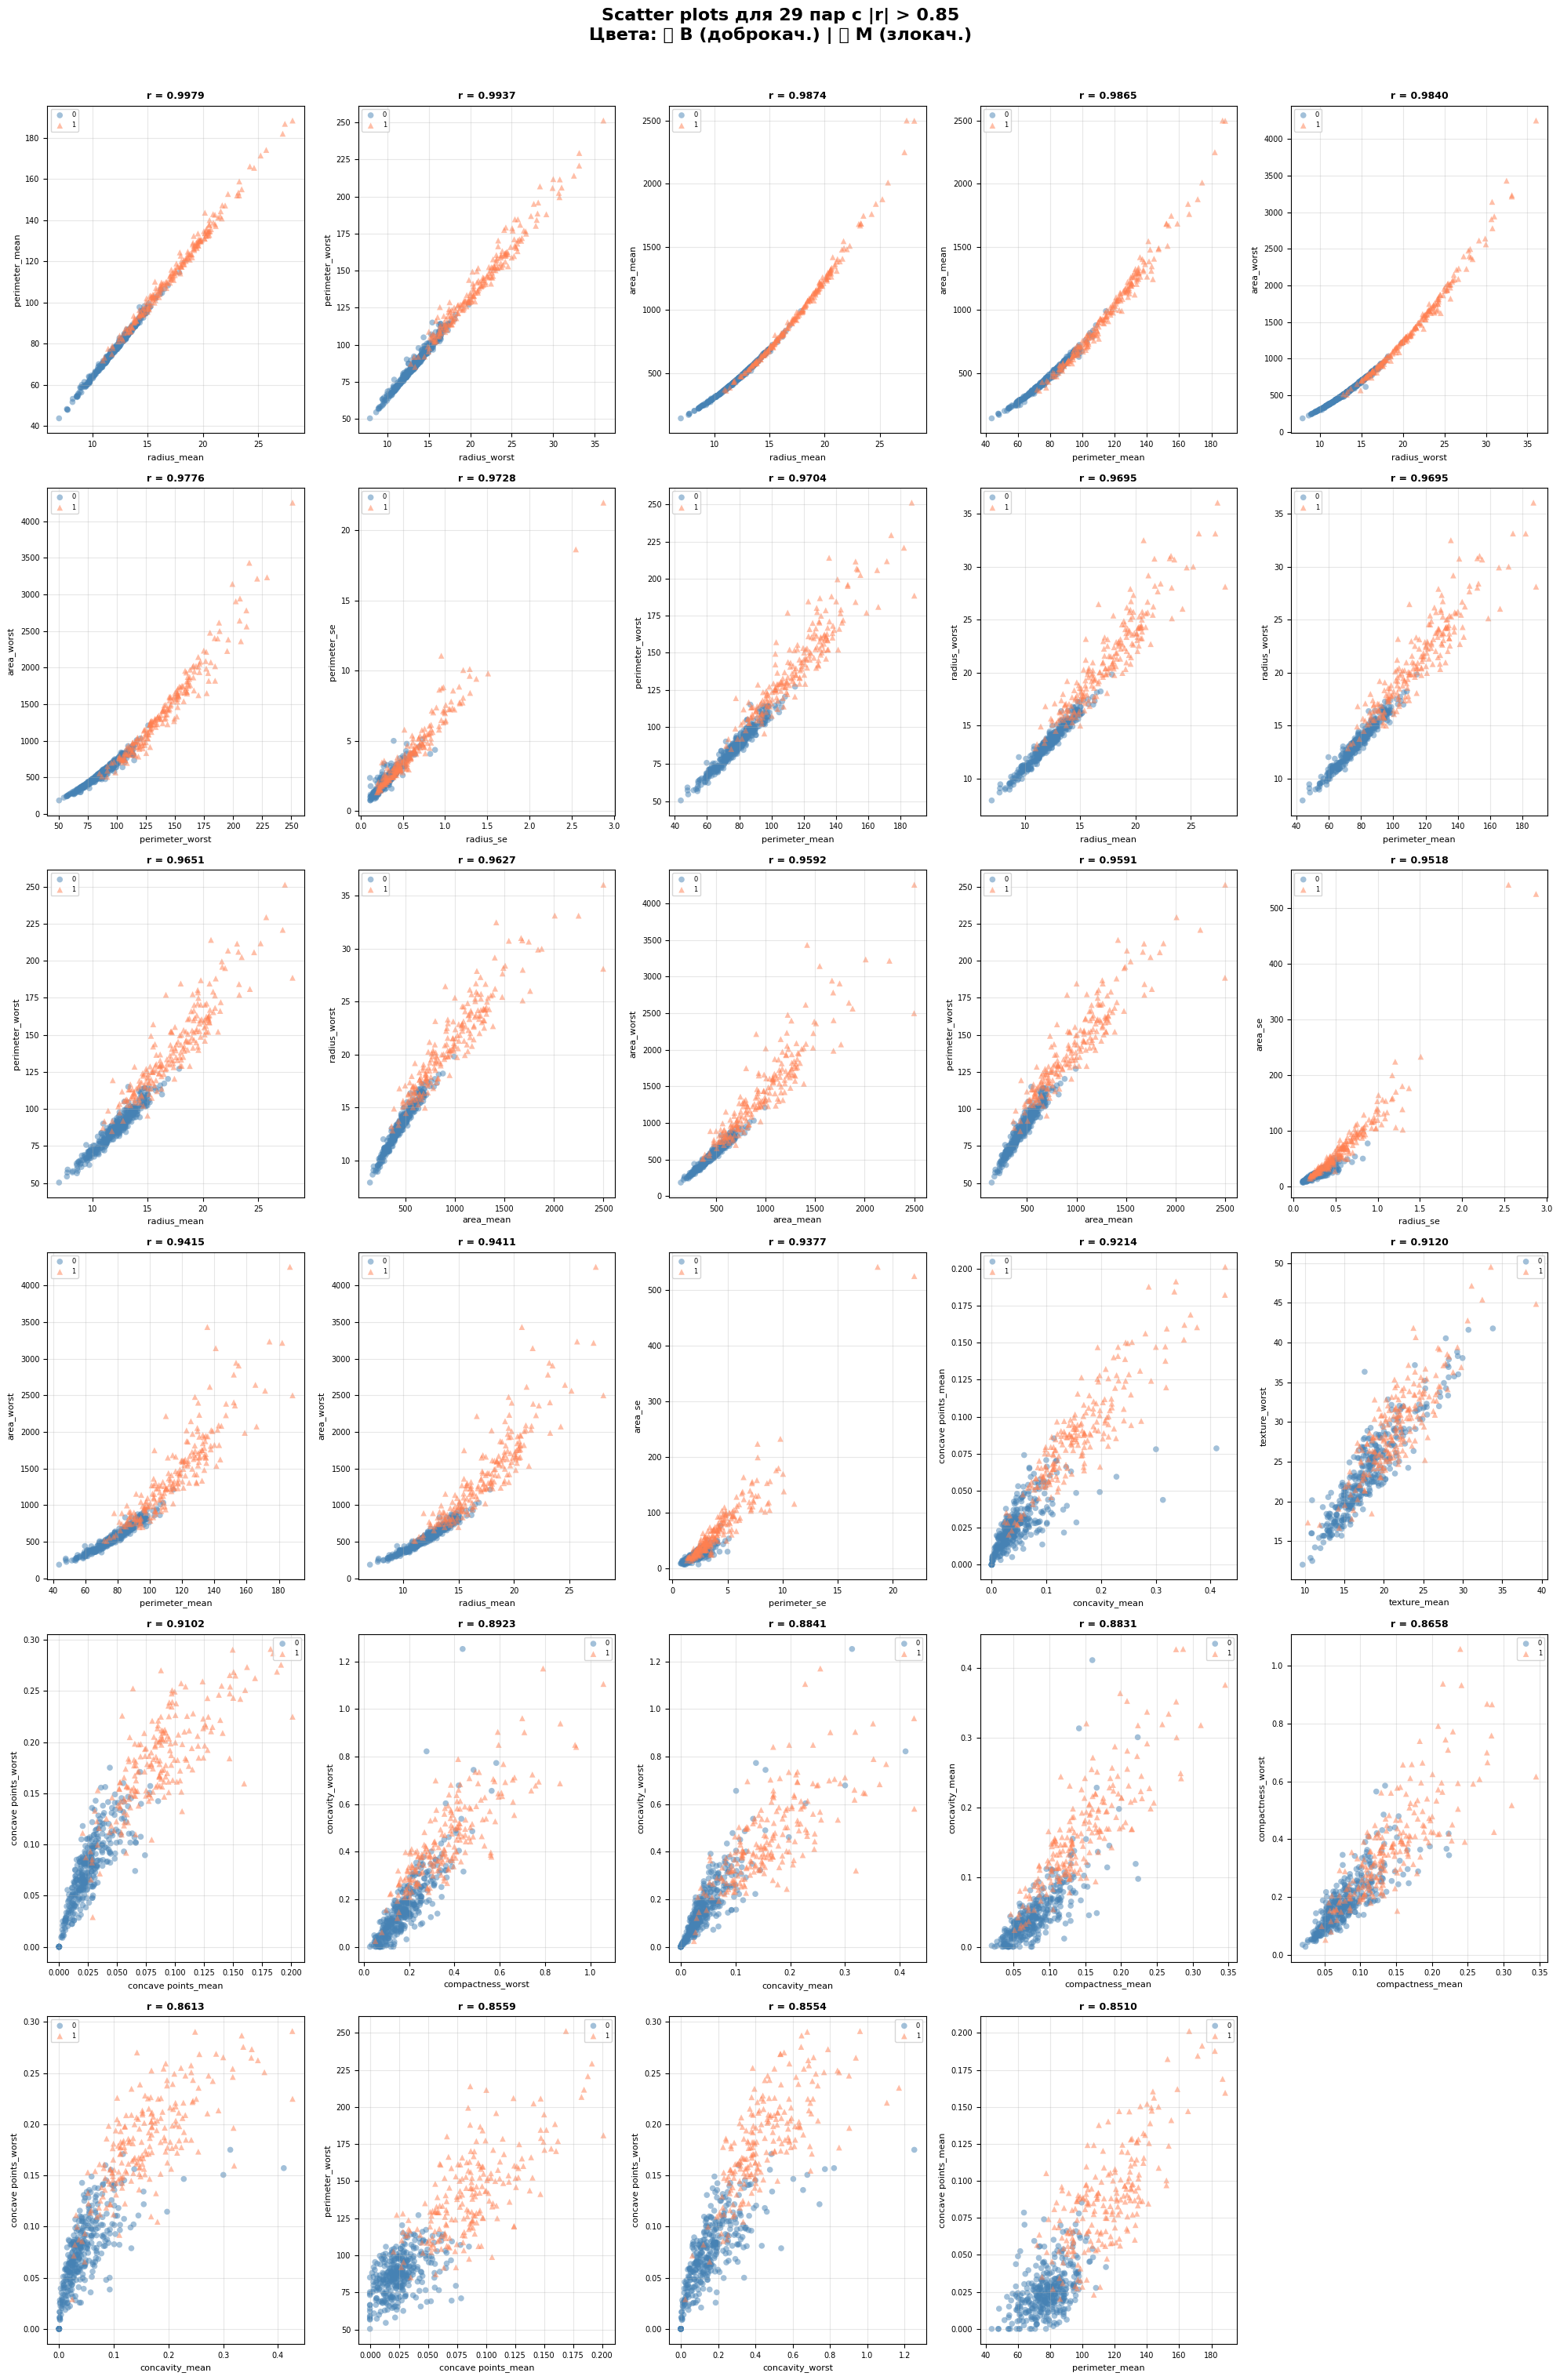

In [21]:


high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.85:
            high_corr_pairs.append({
                'feature1': correlation_matrix.columns[i],
                'feature2': correlation_matrix.columns[j],
                'correlation': corr_val
            })

# Сортируем по убыванию |r|
high_corr_pairs_sorted = sorted(high_corr_pairs,
                                key=lambda x: abs(x['correlation']),
                                reverse=True)

print(f"  Найдено {len(high_corr_pairs_sorted)} пар с |r| > 0.85\n")
#print((high_corr_pairs_sorted))
n_pairs = len(high_corr_pairs_sorted)
n_cols = 5
n_rows = (n_pairs + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()

for idx, pair in enumerate(high_corr_pairs_sorted):
    ax = axes[idx]
    f1, f2, corr = pair['feature1'], pair['feature2'], pair['correlation']

    # Scatter plot с раскраской по диагнозу
    for diagnosis, color, marker, alpha in [
        (0, 'steelblue', 'o', 0.5),
        (1, 'coral', '^', 0.5)
    ]:
        mask = df_clean['diagnosis_binary'] == diagnosis
        ax.scatter(df_clean.loc[mask, f1], df_clean.loc[mask, f2],
                  c=color, marker=marker, alpha=alpha, s=30,
                  edgecolors='none', label=diagnosis)



    ax.set_xlabel(f1, fontsize=8)
    ax.set_ylabel(f2, fontsize=8)
    ax.set_title(f'r = {corr:.4f}', fontsize=9, fontweight='bold')
    ax.legend(fontsize=6, loc='best')
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=7)
    plt.suptitle(f'Scatter plots для {n_pairs} пар с |r| > 0.85\nЦвета: 🔵 B (доброкач.) | 🔴 M (злокач.)',
                fontsize=16, fontweight='bold', y=1.01)

for idx in range(n_pairs, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

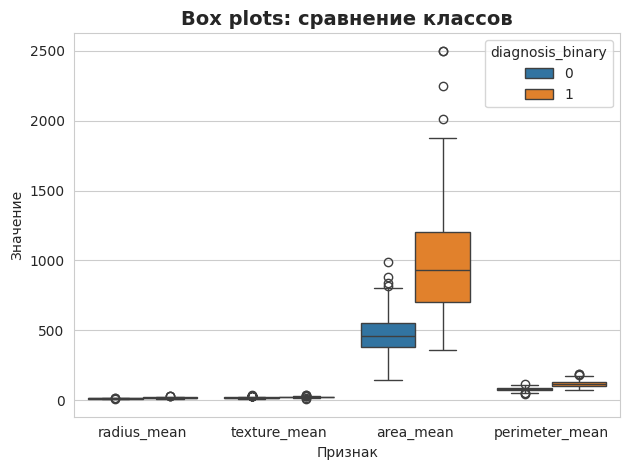

In [55]:
#Box plots для сравнения классов
df_melted = df_clean.melt(id_vars=['diagnosis_binary'],
                     value_vars=['radius_mean', 'texture_mean', 'area_mean','perimeter_mean'],
                     var_name='Признак', value_name='Значение')
sns.boxplot(x='Признак', y='Значение', hue='diagnosis_binary', data=df_melted)
plt.title('Box plots: сравнение классов', fontsize=14, fontweight='bold')


plt.tight_layout()
plt.show()

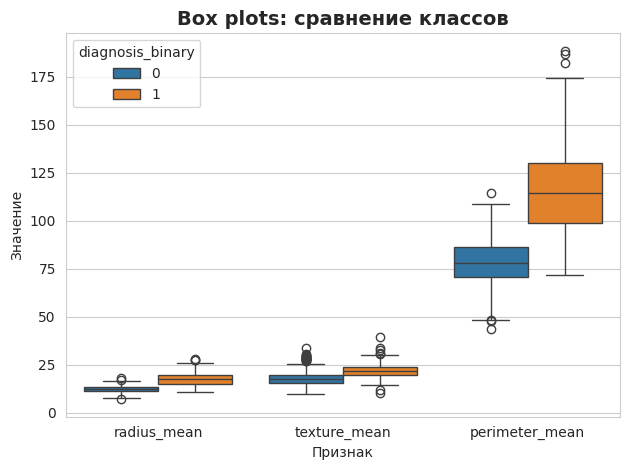

In [79]:
#Box plots для сравнения классов
df_melted = df_clean.melt(id_vars=['diagnosis_binary'],
                     value_vars=['radius_mean', 'texture_mean','perimeter_mean'],
                     var_name='Признак', value_name='Значение')
sns.boxplot(x='Признак', y='Значение', hue='diagnosis_binary', data=df_melted)
plt.title('Box plots: сравнение классов', fontsize=14, fontweight='bold')


plt.tight_layout()
plt.show()

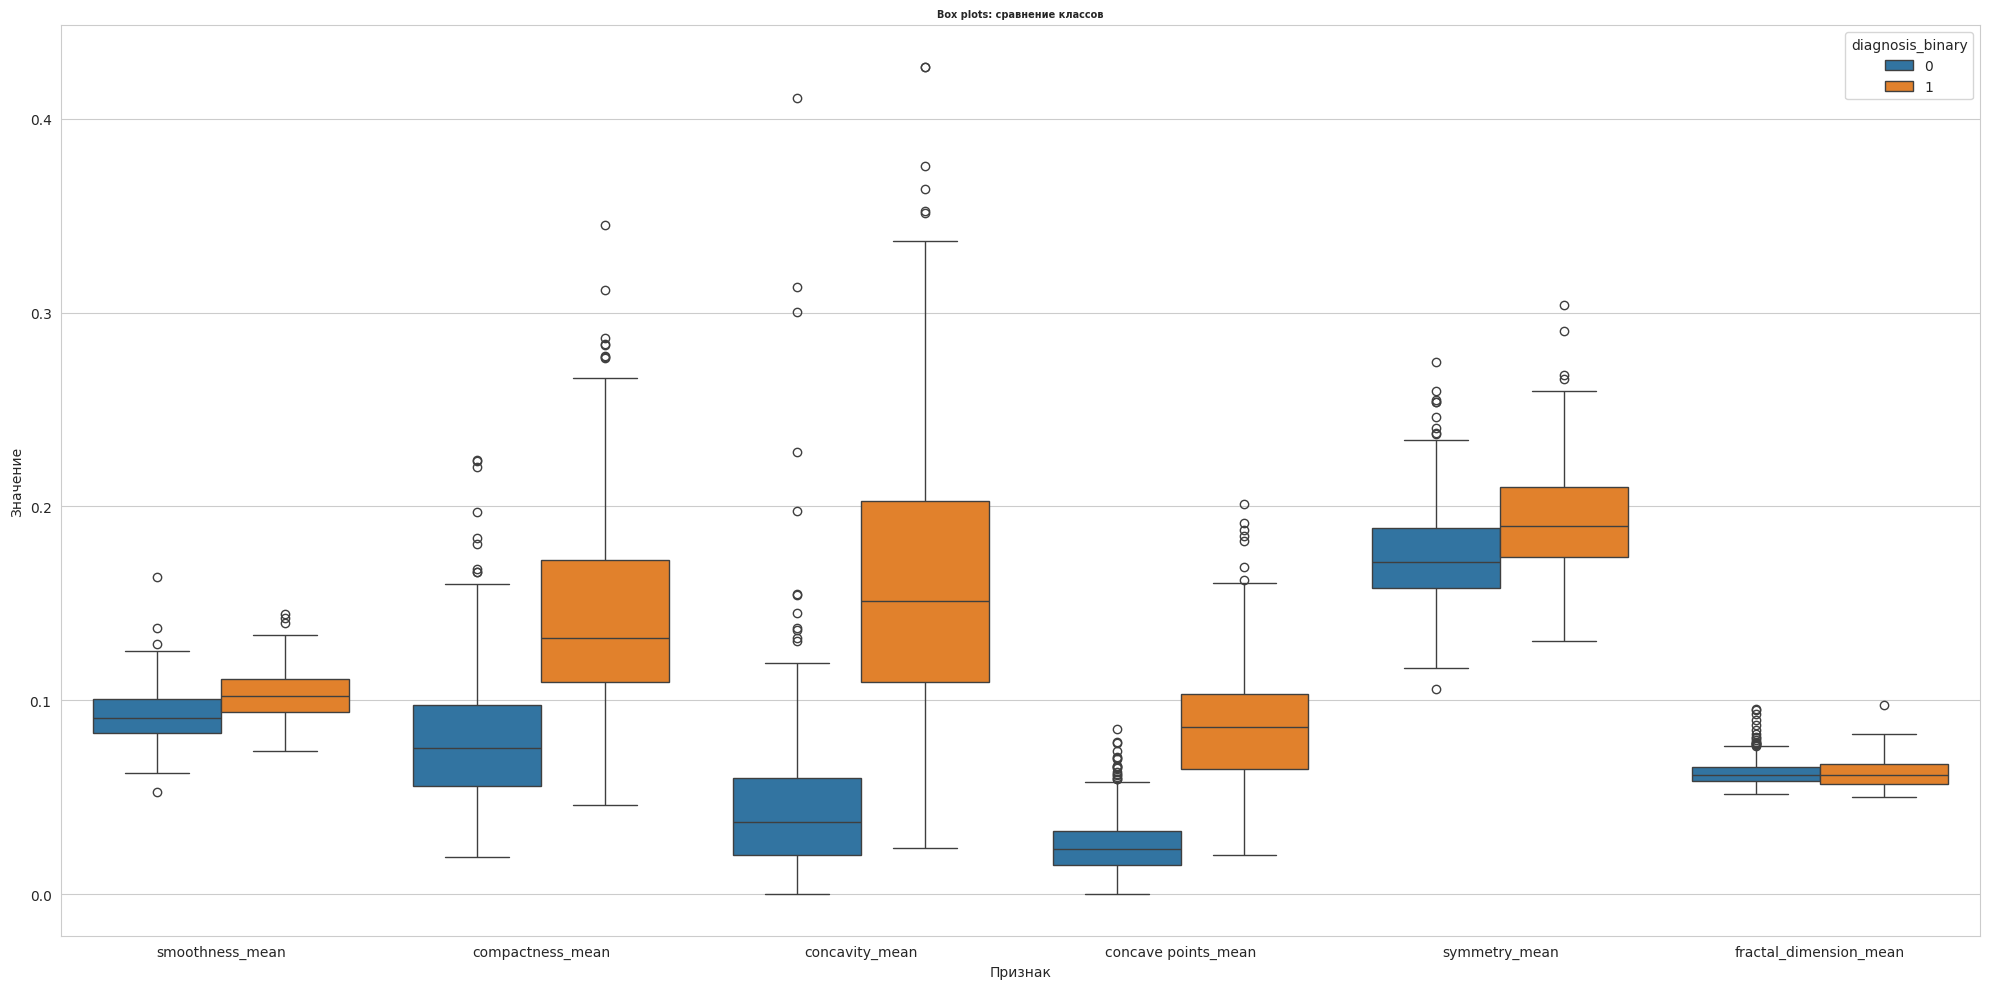

In [78]:
plt.figure(figsize=(20, 10))
df_melted = df_clean.melt(id_vars=['diagnosis_binary'],value_vars=[ 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean'],
                     var_name='Признак', value_name='Значение')
sns.boxplot(x='Признак', y='Значение', hue='diagnosis_binary', data=df_melted)
plt.title('Box plots: сравнение классов', fontsize=7, fontweight='bold')


plt.tight_layout()
plt.show()

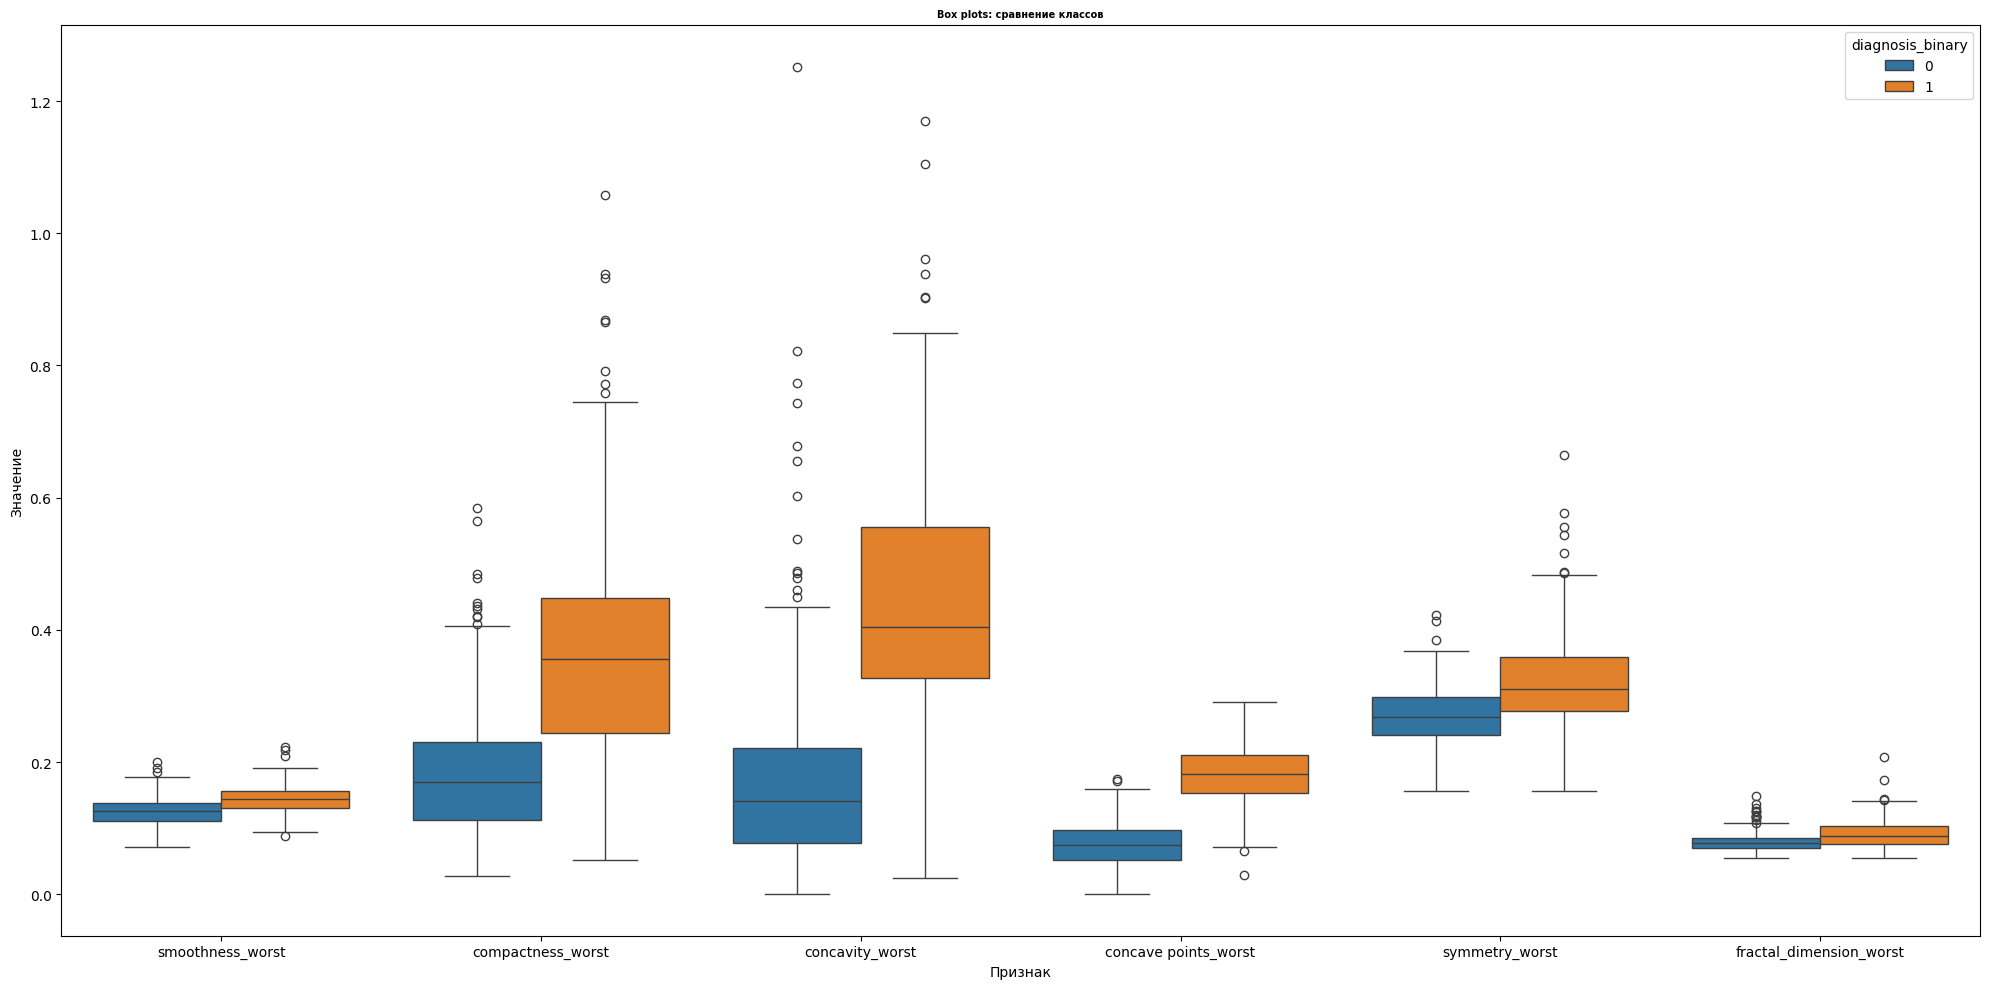

In [18]:
plt.figure(figsize=(20, 10))
df_melted = df_clean.melt(id_vars=['diagnosis_binary'],value_vars=[ 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst'],
                     var_name='Признак', value_name='Значение')
sns.boxplot(x='Признак', y='Значение', hue='diagnosis_binary', data=df_melted)
plt.title('Box plots: сравнение классов', fontsize=7, fontweight='bold')


plt.tight_layout()
plt.show()

In [83]:
cols = ['radius_mean', 'texture_mean', 'area_mean','perimeter_mean','smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean' ]
# Корреляция с целевой переменной
target_corr = df_clean[cols].corrwith(df_clean['diagnosis_binary']).sort_values(ascending=False)
print(target_corr)

concave points_mean       0.776614
perimeter_mean            0.742636
radius_mean               0.730029
area_mean                 0.708984
concavity_mean            0.696360
compactness_mean          0.596534
texture_mean              0.415185
smoothness_mean           0.358560
symmetry_mean             0.330499
fractal_dimension_mean   -0.012838
dtype: float64


📊 Все признаки в одной сетке 6×5
30


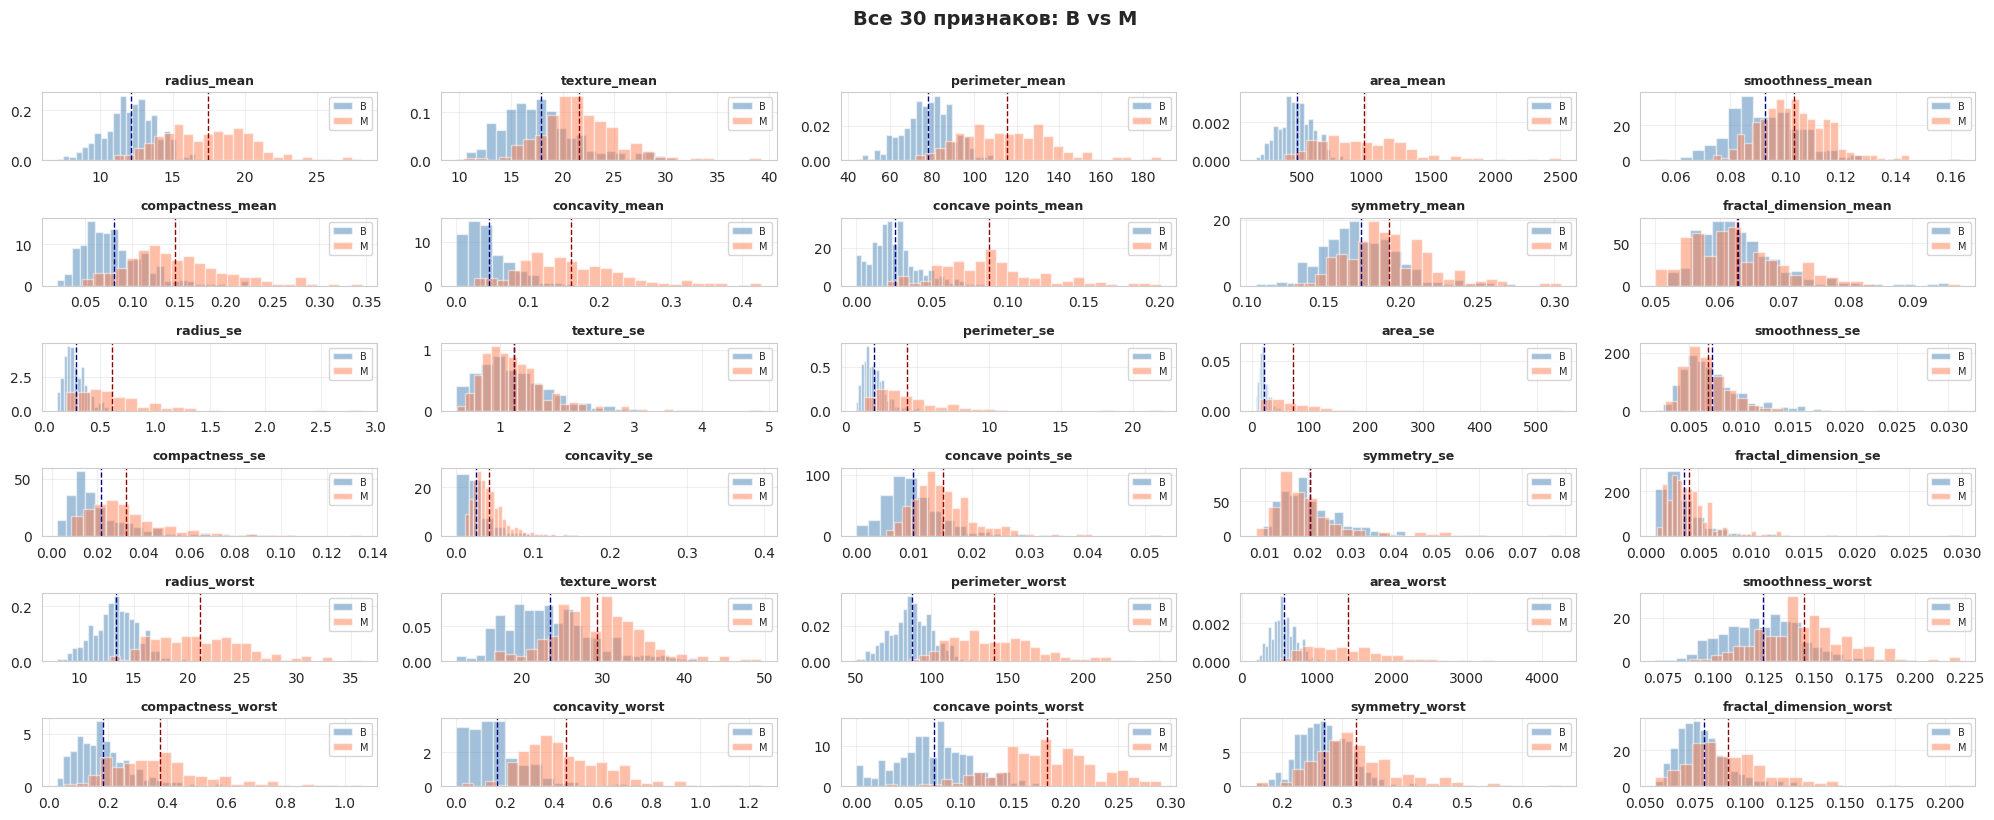

In [41]:


# Настройка
sns.set_style("whitegrid")

features = [col for col in df_clean.columns if col not in ['diagnosis_binary']]
df_B = df_clean[df_clean['diagnosis_binary'] == 0]
df_M = df_clean[df_clean['diagnosis_binary'] == 1]
'''
features = [col for col in df.columns if col not in ['id', 'diagnosis','Unnamed: 32']]
df_B = df[df['diagnosis'] == 'B']
df_M = df[df['diagnosis'] == 'M']
'''
# Функция для построения гистограммы одного признака
def plot_feature_histogram(feature, bins=20):
    plt.figure(figsize=(45, 15))

    # Гистограммы
    plt.hist(df_B[feature], bins=bins, alpha=0.6, color='steelblue',
             label='B (Доброкач.)', density=True, edgecolor='navy', linewidth=1)
    plt.hist(df_M[feature], bins=bins, alpha=0.6, color='coral',
             label='M (Злокач.)', density=True, edgecolor='darkred', linewidth=1)

    # Средние значения
    for data, color, style in [(df_B, 'navy', '--'), (df_M, 'darkred', '--')]:
        plt.axvline(data[feature].mean(), color=color, linestyle=style, linewidth=2, alpha=0.8)
        plt.axvline(data[feature].median(), color=color, linestyle=':', linewidth=1.5, alpha=0.5)

    # Статистика
    plt.text(0.98, 0.95, f'B: μ={df_B[feature].mean():.3f}, σ={df_B[feature].std():.3f}\n'
                         f'M: μ={df_M[feature].mean():.3f}, σ={df_M[feature].std():.3f}',
             transform=plt.gca().transAxes, fontsize=10, ha='right', va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.title(feature, fontsize=14, fontweight='bold')
    plt.xlabel('Значение'); plt.ylabel('Плотность')
    plt.legend(loc='upper left'); plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

# Функция для сетки графиков
def plot_features_grid(feature_list, rows, cols, title, figsize=(20, 8)):
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten()

    for i, feature in enumerate(feature_list):
        axes[i].hist(df_B[feature], bins=25, alpha=0.5, color='steelblue', label='B', density=True)
        axes[i].hist(df_M[feature], bins=25, alpha=0.5, color='coral', label='M', density=True)
        axes[i].axvline(df_B[feature].mean(), color='navy', linestyle='--', linewidth=1)
        axes[i].axvline(df_M[feature].mean(), color='darkred', linestyle='--', linewidth=1)
        axes[i].set_title(feature, fontsize=9, fontweight='bold')
        axes[i].legend(fontsize=7); axes[i].grid(True, alpha=0.3)

    for i in range(len(feature_list), len(axes)):
        axes[i].axis('off')

    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout();
    plt.show()

# 1. ВСЕ 30 ГРАФИКОВ В ОДНОЙ СЕТКЕ
print("📊 Все признаки в одной сетке 6×5")
print(len(features))
plot_features_grid(features, 6, 5, 'Все 30 признаков: B vs M')


In [11]:
cols = ['radius_mean', 'texture_mean', 'area_mean','perimeter_mean','smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean' ]
# Корреляция с целевой переменной
target_corr = df_clean[cols].corrwith(df_clean['diagnosis_binary']).sort_values(ascending=False)
print(target_corr)

concave points_mean       0.776614
perimeter_mean            0.742636
radius_mean               0.730029
area_mean                 0.708984
concavity_mean            0.696360
compactness_mean          0.596534
texture_mean              0.415185
smoothness_mean           0.358560
symmetry_mean             0.330499
fractal_dimension_mean   -0.012838
dtype: float64


In [24]:

 #['radius_worst', 'texture_worst', 'area_worst','perimeter_worst','smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst' ]
cols = df_clean.columns.tolist()
# Корреляция с целевой переменной
target_corr = df_clean[cols].corrwith(df_clean['diagnosis_binary']).sort_values(ascending=False)
print(target_corr)

diagnosis_binary           1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se               -0

In [66]:
df_clean.columns.tolist()

['radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'smoothness_mean',
 'compactness_mean',
 'concavity_mean',
 'concave points_mean',
 'symmetry_mean',
 'fractal_dimension_mean',
 'radius_se',
 'texture_se',
 'perimeter_se',
 'area_se',
 'smoothness_se',
 'compactness_se',
 'concavity_se',
 'concave points_se',
 'symmetry_se',
 'fractal_dimension_se',
 'radius_worst',
 'texture_worst',
 'perimeter_worst',
 'area_worst',
 'smoothness_worst',
 'compactness_worst',
 'concavity_worst',
 'concave points_worst',
 'symmetry_worst',
 'fractal_dimension_worst',
 'diagnosis_binary']


  Параметры по умолчанию:
    algorithm: auto
    leaf_size: 30
    metric: minkowski
    metric_params: None
    n_jobs: None
    n_neighbors: 5
    p: 2
    weights: uniform

📊  ОЦЕНКА МОДЕЛИ «ИЗ КОРОБКИ»

  Accuracy:  0.9649 (96.49%)
  Precision: 1.0000
  Recall:    0.9062
  F1-score:  0.9508

  5-fold CV на train:
    Scores: [0.9875     0.9875     0.975      0.98734177 0.91139241]
    Среднее: 0.9697 ± 0.0296

📈  ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ


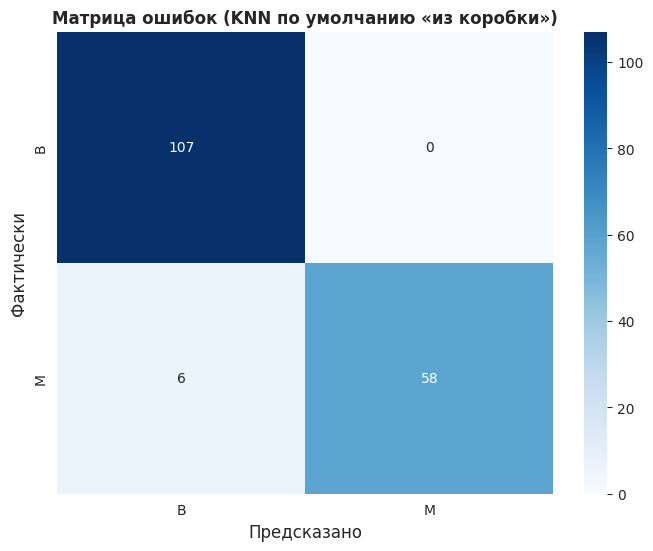

In [79]:
y = df_clean['diagnosis_binary']
X = df_clean.drop('diagnosis_binary', axis=1)


# Разделение на train/test (стратифицированное)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Модель с дефолтными параметрами
knn_default = KNeighborsClassifier()

print("\n  Параметры по умолчанию:")
for param, value in knn_default.get_params().items():
    print(f"    {param}: {value}")

# Обучение
knn_default.fit(X_train_scaled, y_train)

# Предсказания
y_pred_default = knn_default.predict(X_test_scaled)
y_pred_proba_default = knn_default.predict_proba(X_test_scaled)[:, 1]

#  ОЦЕНКА МОДЕЛИ

print("\n" + "="*60)
print("📊  ОЦЕНКА МОДЕЛИ «ИЗ КОРОБКИ»")
print("="*60)

# Метрики
accuracy_def = accuracy_score(y_test, y_pred_default)
precision_def = precision_score(y_test, y_pred_default)
recall_def = recall_score(y_test, y_pred_default)
f1_def = f1_score(y_test, y_pred_default)

print(f"\n  Accuracy:  {accuracy_def:.4f} ({accuracy_def*100:.2f}%)")
print(f"  Precision: {precision_def:.4f}")
print(f"  Recall:    {recall_def:.4f}")
print(f"  F1-score:  {f1_def:.4f}")


# Кросс-валидация
cv_scores = cross_val_score(knn_default, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"\n  5-fold CV на train:")
print(f"    Scores: {cv_scores}")
print(f"    Среднее: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# ═══════════════════════════════════════════════════════════
# ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ═══════════════════════════════════════════════════════════
print("\n" + "="*60)
print("📈  ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")

plt.figure(figsize=(8, 6))

# Матрица ошибок
cm_default = confusion_matrix(y_test, y_pred_default)
sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues',
            xticklabels=['B', 'M'], yticklabels=['B', 'M'])
plt.title('Матрица ошибок (KNN по умолчанию «из коробки»)', fontweight='bold', fontsize=12)
plt.xlabel('Предсказано', fontsize=12)
plt.ylabel('Фактически', fontsize=12)
plt.show()

🤖 ПОСТРОЕНИЕ KNN МОДЕЛИ

📊 1. Подготовка данных

  Train: 398 образцов
  Test:  171 образцов
  ✅ Данные стандартизированы

🔍 2. Подбор оптимального k

  Лучший k: 13
  Лучший CV score: 0.9574


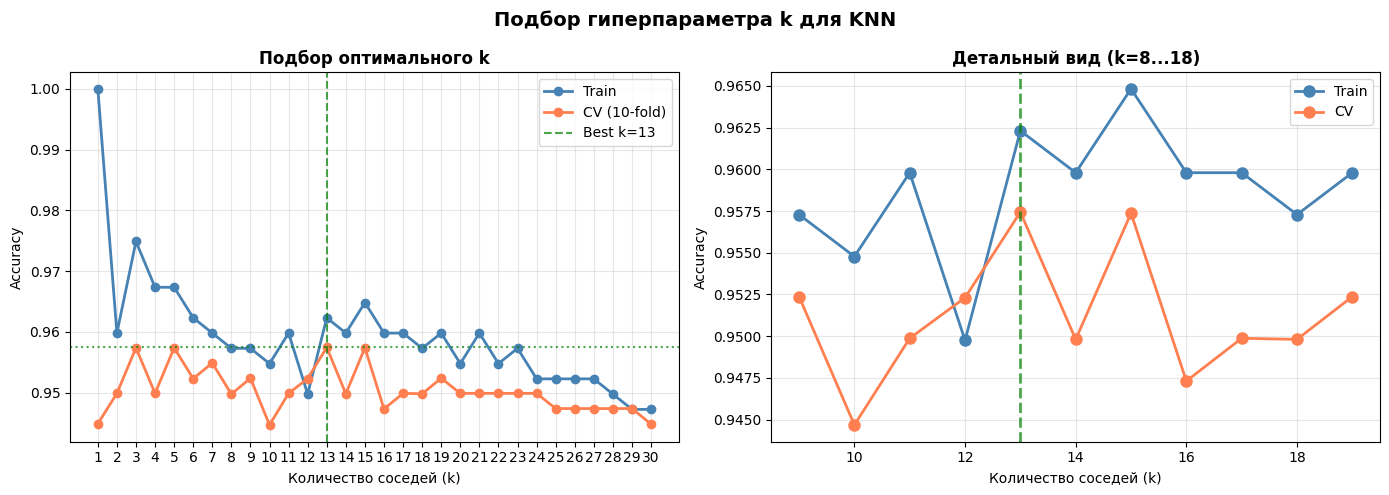


🔧 3. GridSearchCV - полный подбор параметров

  Лучшие параметры: {'metric': 'manhattan', 'n_neighbors': 5, 'p': 1, 'weights': 'uniform'}
  Лучший CV score: 0.9522

🎓 4. Обучение финальной модели
  Модель обучена!
  Параметры: {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'manhattan', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 1, 'weights': 'uniform'}

📊 5. Оценка модели на тестовой выборке

  Accuracy:  0.9708
  Precision: 0.9836
  Recall:    0.9375
  F1-score:  0.9600
  ROC-AUC:   0.9890

  Отчет классификации:
               precision    recall  f1-score   support

B (Доброкач.)       0.96      0.99      0.98       107
  M (Злокач.)       0.98      0.94      0.96        64

     accuracy                           0.97       171
    macro avg       0.97      0.96      0.97       171
 weighted avg       0.97      0.97      0.97       171


📈 6. Визуализация результатов


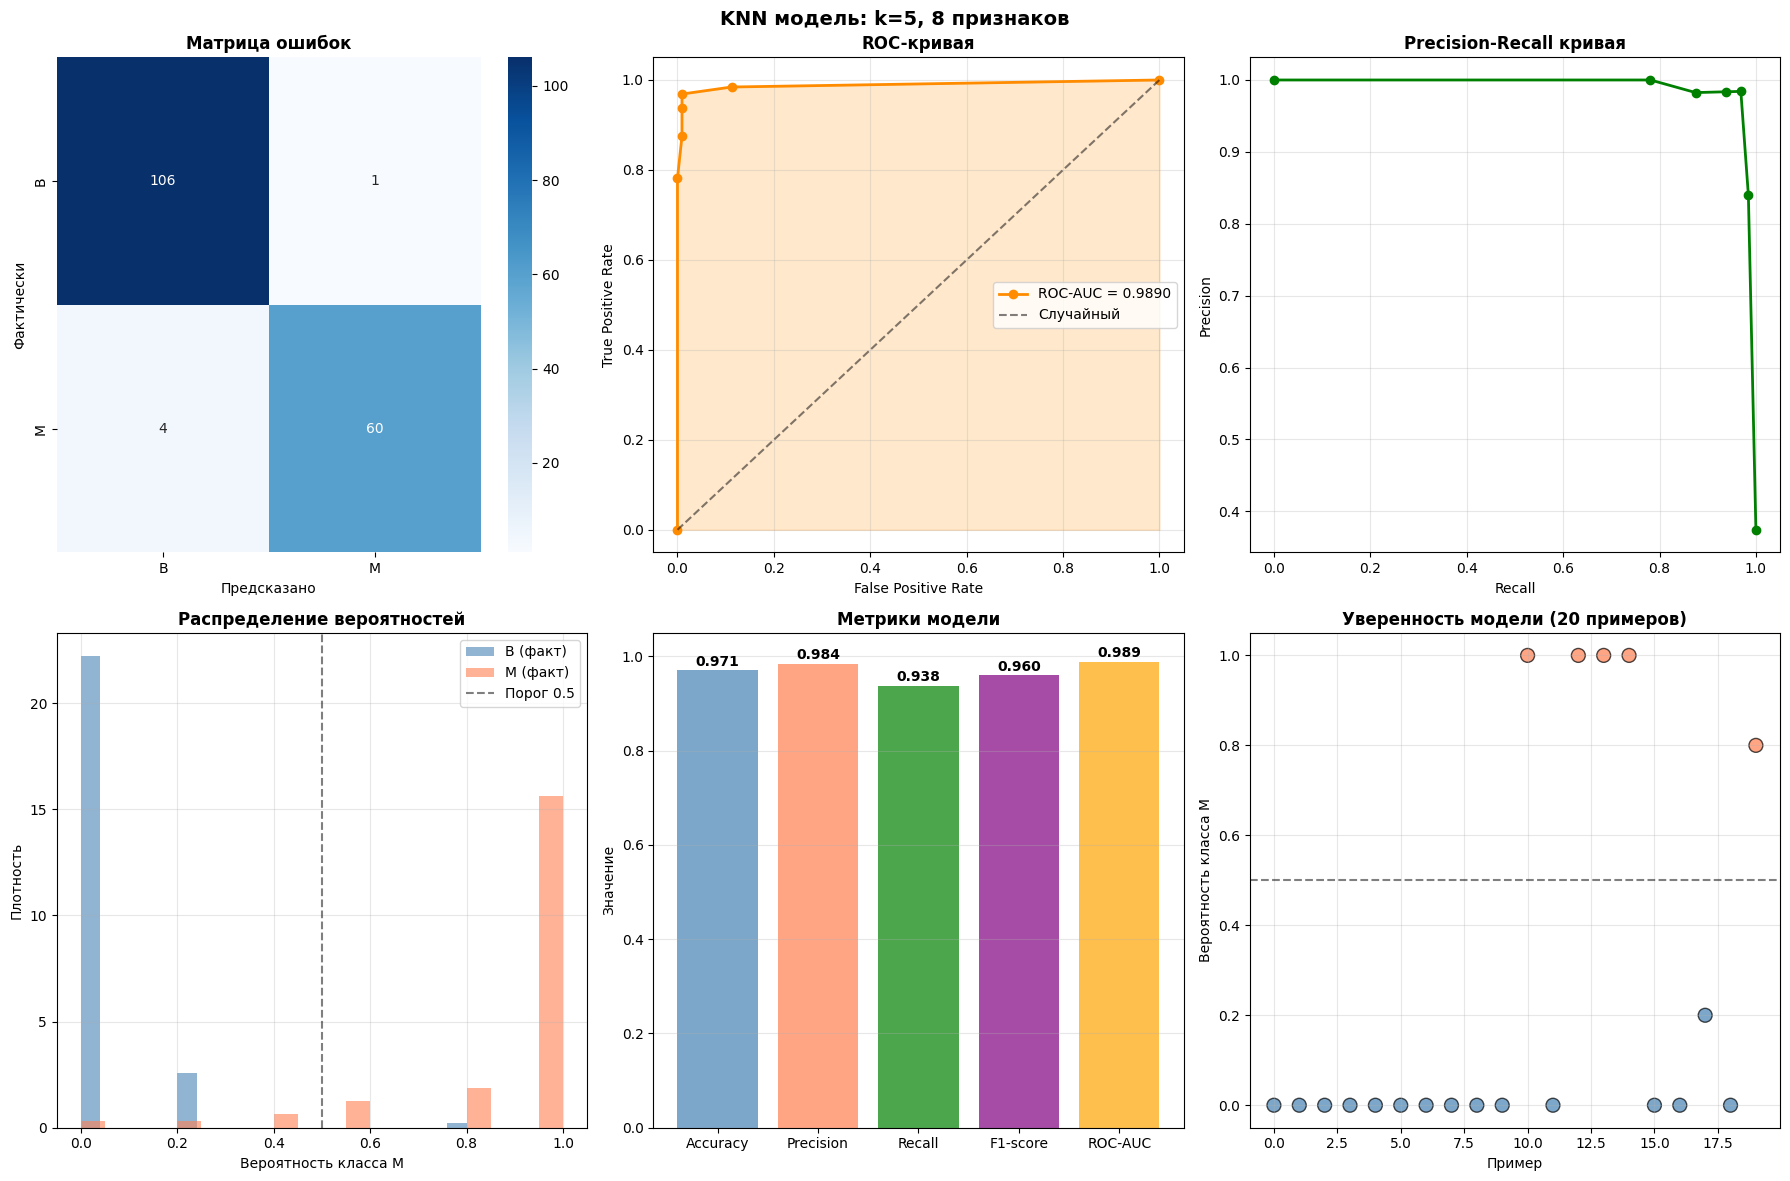


🔍 7. Анализ ошибок

  Всего ошибок: 5 из 171 (2.9%)

  Примеры ошибок:
  Индекс   Факт   Предск   Вероятность M   Уверенность
  --------------------------------------------------
  21       M      B        0.0000          1.0000
  51       M      B        0.4000          0.6000
  148      M      B        0.2000          0.8000
  155      B      M        0.8000          0.8000
  159      M      B        0.4000          0.6000

🔄 8. Кросс-валидация финальной модели

  10-fold CV scores: [0.95       0.975      0.95       1.         0.95       0.95
 0.95       1.         0.92307692 0.92307692]
  Среднее: 0.9571 ± 0.0256
  Мин: 0.9231
  Макс: 1.0000

🏆 ИТОГОВАЯ СВОДКА

📊 ДАННЫЕ:
   • Признаков: 8
   • Train: 398 | Test: 171
   • Масштабирование: StandardScaler

⚙️ МОДЕЛЬ:
   • Алгоритм: K-Nearest Neighbors
   • k (соседей): 5
   • Веса: uniform
   • Метрика: manhattan

📈 РЕЗУЛЬТАТЫ:
   • Accuracy:  0.9708 (97.08%)
   • Precision: 0.9836
   • Recall:    0.9375
   • F1-score:  0.9600
   • RO

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve)


print("="*60)
print("🤖 ПОСТРОЕНИЕ KNN МОДЕЛИ")
print("="*60)

# ═══════════════════════════════════════════════════════════
# 1. ПОДГОТОВКА ДАННЫХ
# ═══════════════════════════════════════════════════════════
print("\n📊 1. Подготовка данных")

# Целевая переменная
y = df_clean['diagnosis_binary']

# Набор признаков (подбираем на основе проведенного анализ)
'''
features_knn = [
     'texture_worst', 'area_mean','perimeter_worst','smoothness_worst',
    'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]
'''
features_knn = [
    'concave points_worst','radius_worst','concavity_mean','compactness_mean','texture_worst','smoothness_worst',
'symmetry_worst',
'fractal_dimension_worst'
]
X = df_clean[features_knn]


# Разделение на train/test (стратифицированное)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\n  Train: {len(X_train)} образцов")
print(f"  Test:  {len(X_test)} образцов")

# Стандартизация
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"  ✅ Данные стандартизированы")

# ═══════════════════════════════════════════════════════════
# 2. ПОДБОР ОПТИМАЛЬНОГО K
# ═══════════════════════════════════════════════════════════
print("\n" + "="*60)
print("🔍 2. Подбор оптимального k")

k_values = range(1, 31)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

train_scores = []
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='manhattan')

    # Точность на train
    knn.fit(X_train_scaled, y_train)
    train_scores.append(knn.score(X_train_scaled, y_train))

    # Кросс-валидация
    cv_score = cross_val_score(knn, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    cv_scores.append(cv_score.mean())

# Находим лучший k
best_k = k_values[np.argmax(cv_scores)]
best_cv_score = max(cv_scores)

print(f"\n  Лучший k: {best_k}")
print(f"  Лучший CV score: {best_cv_score:.4f}")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График accuracy vs k
axes[0].plot(k_values, train_scores, 'o-', color='steelblue', label='Train', linewidth=2)
axes[0].plot(k_values, cv_scores, 'o-', color='coral', label='CV (10-fold)', linewidth=2)
axes[0].axvline(best_k, color='green', linestyle='--', alpha=0.7, label=f'Best k={best_k}')
axes[0].axhline(best_cv_score, color='green', linestyle=':', alpha=0.7)
axes[0].set_xlabel('Количество соседей (k)')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Подбор оптимального k', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(k_values)

# Zoom на лучшие значения
zoom_range = slice(max(0, best_k-5), min(len(k_values), best_k+6))
axes[1].plot(list(k_values)[zoom_range], train_scores[zoom_range], 'o-',
             color='steelblue', label='Train', linewidth=2, markersize=8)
axes[1].plot(list(k_values)[zoom_range], cv_scores[zoom_range], 'o-',
             color='coral', label='CV', linewidth=2, markersize=8)
axes[1].axvline(best_k, color='green', linestyle='--', alpha=0.7, linewidth=2)
axes[1].set_xlabel('Количество соседей (k)')
axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'Детальный вид (k={best_k-5}...{best_k+5})', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Подбор гиперпараметра k для KNN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════
# 3. GridSearchCV для полного подбора
# ═══════════════════════════════════════════════════════════
print("\n" + "="*60)
print("🔧 3. GridSearchCV - полный подбор параметров")

param_grid = {
    'n_neighbors': [5],#([best_k], #range(3, 12),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]  # 1=manhattan, 2=euclidean
}

knn_base = KNeighborsClassifier()
grid_search = GridSearchCV(knn_base, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
grid_search.fit(X_train_scaled, y_train)

print(f"\n  Лучшие параметры: {grid_search.best_params_}")
print(f"  Лучший CV score: {grid_search.best_score_:.4f}")

# ═══════════════════════════════════════════════════════════
# 4. ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ
# ═══════════════════════════════════════════════════════════
print("\n" + "="*60)
print("🎓 4. Обучение финальной модели")

# Используем лучшие параметры
final_knn = grid_search.best_estimator_
final_knn.fit(X_train_scaled, y_train)

# Предсказания
y_pred = final_knn.predict(X_test_scaled)
y_pred_proba = final_knn.predict_proba(X_test_scaled)[:, 1]

print(f"  Модель обучена!")
print(f"  Параметры: {final_knn.get_params()}")

# ═══════════════════════════════════════════════════════════
# 5. ОЦЕНКА МОДЕЛИ
# ═══════════════════════════════════════════════════════════
print("\n" + "="*60)
print("📊 5. Оценка модели на тестовой выборке")
print("="*60)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\n  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-score:  {f1:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")

# Детальный отчет
print(f"\n  Отчет классификации:")
print(classification_report(y_test, y_pred, target_names=['B (Доброкач.)', 'M (Злокач.)']))

# ═══════════════════════════════════════════════════════════
# 6. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ═══════════════════════════════════════════════════════════
print("\n" + "="*60)
print("📈 6. Визуализация результатов")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['B', 'M'], yticklabels=['B', 'M'])
axes[0, 0].set_title('Матрица ошибок', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Предсказано')
axes[0, 0].set_ylabel('Фактически')

# 2. ROC-кривая
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0, 1].plot(fpr, tpr, 'o-', color='darkorange', linewidth=2, label=f'ROC-AUC = {roc_auc:.4f}')
axes[0, 1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Случайный')
axes[0, 1].fill_between(fpr, tpr, alpha=0.2, color='darkorange')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC-кривая', fontweight='bold', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Precision-Recall кривая
from sklearn.metrics import precision_recall_curve
precisions, recalls, _ = precision_recall_curve(y_test, y_pred_proba)
axes[0, 2].plot(recalls, precisions, 'o-', color='green', linewidth=2)
axes[0, 2].set_xlabel('Recall')
axes[0, 2].set_ylabel('Precision')
axes[0, 2].set_title('Precision-Recall кривая', fontweight='bold', fontsize=12)
axes[0, 2].grid(True, alpha=0.3)

# 4. Распределение вероятностей
axes[1, 0].hist(y_pred_proba[y_test == 0], bins=20, alpha=0.6, color='steelblue',
                label='B (факт)', density=True)
axes[1, 0].hist(y_pred_proba[y_test == 1], bins=20, alpha=0.6, color='coral',
                label='M (факт)', density=True)
axes[1, 0].axvline(0.5, color='black', linestyle='--', alpha=0.5, label='Порог 0.5')
axes[1, 0].set_xlabel('Вероятность класса M')
axes[1, 0].set_ylabel('Плотность')
axes[1, 0].set_title('Распределение вероятностей', fontweight='bold', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 5. Метрики в виде bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
values = [accuracy, precision, recall, f1, roc_auc]
colors = ['steelblue', 'coral', 'green', 'purple', 'orange']
bars = axes[1, 1].bar(metrics, values, color=colors, alpha=0.7)
axes[1, 1].set_ylim([0, 1.05])
axes[1, 1].set_ylabel('Значение')
axes[1, 1].set_title('Метрики модели', fontweight='bold', fontsize=12)
for bar, val in zip(bars, values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', fontweight='bold', fontsize=10)
axes[1, 1].grid(True, alpha=0.3, axis='y')

# 6. Сравнение predict_proba для нескольких примеров
sample_idx = np.random.choice(len(y_test), min(20, len(y_test)), replace=False)
sample_proba = y_pred_proba[sample_idx]
sample_true = y_test.iloc[sample_idx].values
sample_pred = y_pred[sample_idx]

axes[1, 2].scatter(range(len(sample_idx)), sample_proba,
                   c=['steelblue' if t == 0 else 'coral' for t in sample_true],
                   s=100, alpha=0.7, edgecolors='black', linewidth=1)
axes[1, 2].axhline(0.5, color='black', linestyle='--', alpha=0.5)
axes[1, 2].set_xlabel('Пример')
axes[1, 2].set_ylabel('Вероятность класса M')
axes[1, 2].set_title('Уверенность модели (20 примеров)', fontweight='bold', fontsize=12)
axes[1, 2].set_ylim([-0.05, 1.05])
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle(f'KNN модель: k={final_knn.n_neighbors}, {len(features_knn)} признаков',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════
# 7. АНАЛИЗ ОШИБОК
# ═══════════════════════════════════════════════════════════
print("\n" + "="*60)
print("🔍 7. Анализ ошибок")

# Находим неправильные предсказания
errors_mask = y_pred != y_test.values
errors_idx = np.where(errors_mask)[0]

print(f"\n  Всего ошибок: {len(errors_idx)} из {len(y_test)} ({len(errors_idx)/len(y_test)*100:.1f}%)")

if len(errors_idx) > 0:
    print(f"\n  Примеры ошибок:")
    print(f"  {'Индекс':<8} {'Факт':<6} {'Предск':<8} {'Вероятность M':<15} {'Уверенность'}")
    print(f"  {'-'*50}")

    for idx in errors_idx[:5]:  # Первые 5 ошибок
        fact = 'M' if y_test.iloc[idx] == 1 else 'B'
        pred = 'M' if y_pred[idx] == 1 else 'B'
        proba = y_pred_proba[idx]
        confidence = proba if y_pred[idx] == 1 else 1 - proba

        print(f"  {idx:<8} {fact:<6} {pred:<8} {proba:<15.4f} {confidence:.4f}")

# ═══════════════════════════════════════════════════════════
# 8. КРОСС-ВАЛИДАЦИЯ ФИНАЛЬНОЙ МОДЕЛИ
# ═══════════════════════════════════════════════════════════
print("\n" + "="*60)
print("🔄 8. Кросс-валидация финальной модели")

cv_scores_final = cross_val_score(final_knn, X_train_scaled, y_train, cv=10, scoring='accuracy')
print(f"\n  10-fold CV scores: {cv_scores_final}")
print(f"  Среднее: {cv_scores_final.mean():.4f} ± {cv_scores_final.std():.4f}")
print(f"  Мин: {cv_scores_final.min():.4f}")
print(f"  Макс: {cv_scores_final.max():.4f}")


# ═══════════════════════════════════════════════════════════
# 9. ИТОГОВАЯ СВОДКА
# ═══════════════════════════════════════════════════════════
print("\n" + "="*60)
print("🏆 ИТОГОВАЯ СВОДКА")
print("="*60)

summary = f"""
📊 ДАННЫЕ:
   • Признаков: {len(features_knn)}
   • Train: {len(X_train)} | Test: {len(X_test)}
   • Масштабирование: StandardScaler

⚙️ МОДЕЛЬ:
   • Алгоритм: K-Nearest Neighbors
   • k (соседей): {final_knn.n_neighbors}
   • Веса: {final_knn.weights}
   • Метрика: {final_knn.metric}

📈 РЕЗУЛЬТАТЫ:
   • Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)
   • Precision: {precision:.4f}
   • Recall:    {recall:.4f}
   • F1-score:  {f1:.4f}
   • ROC-AUC:   {roc_auc:.4f}
   • CV (10-fold): {cv_scores_final.mean():.4f} ± {cv_scores_final.std():.4f}

✅ Модель правильно классифицирует {accuracy*100:.1f}% образцов!
"""

print(summary)

print("="*60)
print("✅ МОДЕЛЬ KNN УСПЕШНО ПОСТРОЕНА!")
print("="*60)

Выводы: Даже без настройки параметров KNN показывает отличные результаты на этом датасете, но при подборе параметров удалось незначительно повысить точность, и, главное, уменьшить количество ложноотрицательных (M->B) предсказаний вдвое